# Monte Carlo Simulation for Option Pricing

This notebook implements and analyzes European option pricing under the Black--Scholes framework.

Main components:

1. Geometric Brownian Motion simulation.
2. Closed-form Black--Scholes pricing.
3. Monte Carlo pricing with antithetic variates.
4. Volatility sensitivity analysis.
5. Monte Carlo convergence analysis.
6. Greeks estimated with finite differences.

The reusable functions are kept in `option_pricing.py`. This notebook focuses on analysis, plots, and interpretation.

# Model setup

For simplicity, we assume no dividend yield. Under the risk-neutral measure,
the asset follows a geometric Brownian motion with drift equal to the
risk-free rate.

$$
dS_t = S_t \left( r\,dt + \sigma\, dW_t \right),
$$

where $S_t$ represents the price of the asset at time $t$, $r$ is the constant interest rate and $W_t$ is a standard Brownian motion. The solution to the previous SDE is given by,

$$
S_t = S_0 \exp\left((r-\frac{1}{2}\sigma^2)t + \sigma \sqrt{t}Z\right), \quad Z \sim N(0,1).
$$

Also, the terminal value of a european call and put, are respectively,

$$
C = e^{-rT} \mathbb{E}[(S_T-K)^+], \ \ P = e^{-rT} \mathbb{E}[(K - S_T)^+]. 
$$

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from option_pricing import *

PROJECT_ROOT = Path.cwd()

OUTPUT_DIR = PROJECT_ROOT / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

pd.options.display.float_format = "{:,.6f}".format

# Base inputs

The following parameters are chosen randomly to test the code. Nevertheless, the parameters could be chosen by performing a calibration of a real asset.

In [3]:
params = {
    'S0': 100, # Initial stock price
    'K': 100, # Strike price
    'T': 1, # Time to maturity in years
    'r': 0.05, # Risk-free interest rate
    'sigma': 0.2, # Volatility of the underlying asset
    'option type': 'call' # Type of option: 'call' or 'put'
}

params

{'S0': 100, 'K': 100, 'T': 1, 'r': 0.05, 'sigma': 0.2, 'option type': 'call'}

# Black-scholes and Monte Carlo comparison

In this section we simulate trajectories for a GBM. After that, we compute the initial value of the options (call or put) through the analytical Black-Scholes formula, and compare it with the Monte Carlo approximation.

The procedure to calculate the Monte Carlo approximation for the options is:

1. Simulate terminal asset prices under the risk-neutral measure:
   
   $$
   S_T = S_0 \exp\left((r - \tfrac12 \sigma^2)T + \sigma \sqrt{T} Z\right)
   $$

2. Compute the option payoff for each simulation:
   
   $$
   (S_T - K)^+
   $$

3. Discount the payoff back to present value:
   
   $$
   e^{-rT}(S_T - K)^+
   $$

4. Estimate the option price by averaging across all simulations:
   
   $$
   V_0 \approx \frac{1}{N}\sum_{i=1}^N e^{-rT}(S_T^{(i)} - K)^+
   $$

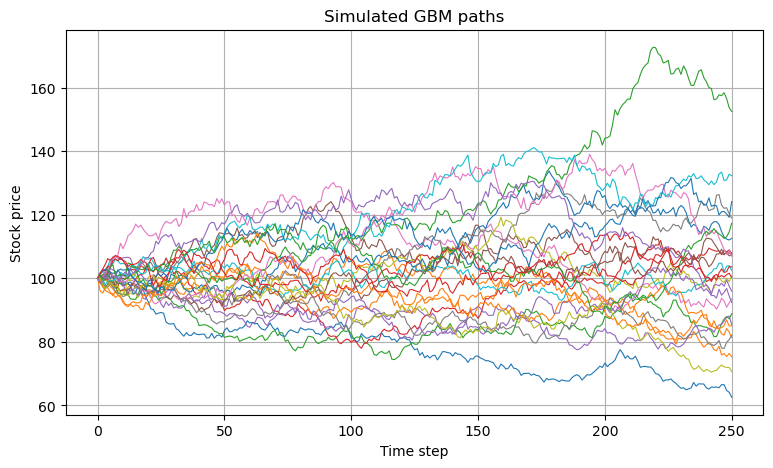

In [4]:
paths = simulate_gbm_paths(
    params=params,
    n_paths=1_000,
    n_steps=250,
    seed=7,
)

plot_sample_paths(paths, 25, OUTPUT_DIR)

In [5]:
bs_price = black_scholes_price(params)
mc_price = monte_carlo_price(params, n_sim=100_000, seed=42, antithetic = False)

pricing_df = pd.DataFrame([mc_price])
pricing_df

,mc_price,bs_price,absolute_error,standard_error,ci_95_low,ci_95_high,n_sim,antithetic
0,10.420541,10.450584,0.030042,0.046770,10.328872,10.512210,100000,False


## Monte Carlo convergence

As the number of simulated paths increases, the Monte Carlo estimate should converge toward the Black--Scholes benchmark. The estimator has sampling error, so confidence intervals are also shown.

In [6]:
conv_df = convergence_study(params, seed = 42)

conv_df.to_csv(OUTPUT_DIR / "convergence_study.csv", index=False)

conv_df


,n_sim,mc_price,bs_price,absolute_error,standard_error,ci_95_low,ci_95_high,antithetic
0,1000,9.911980,10.450584,0.538604,0.448345,9.033223,10.790736,False
1,5000,10.307307,10.450584,0.143277,0.205211,9.905093,10.709521,False
2,10000,10.524882,10.450584,0.074298,0.148472,10.233876,10.815887,False
3,25000,10.509671,10.450584,0.059087,0.094076,10.325281,10.694060,False
4,50000,10.371029,10.450584,0.079554,0.065506,10.242637,10.499421,False
5,100000,10.394138,10.450584,0.056446,0.046355,10.303282,10.484994,False
6,250000,10.453803,10.450584,0.003219,0.029407,10.396165,10.511442,False


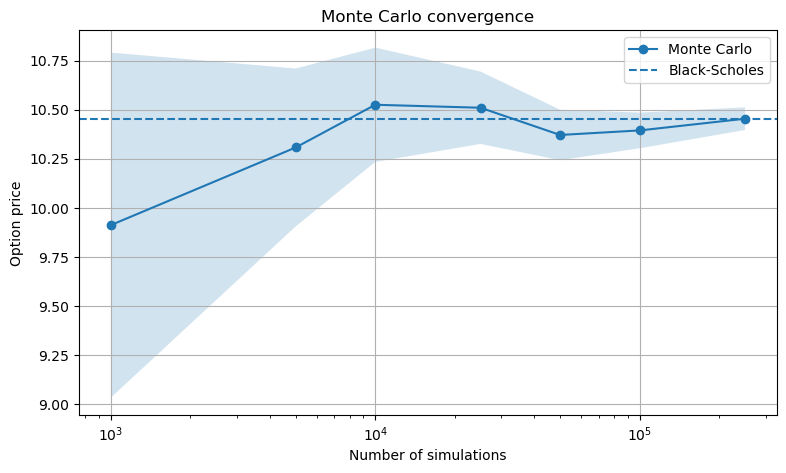

In [7]:
# Plot of the Monte Carlo price convergence to the Black-Scholes price. Confidence intervals are shown as shaded areas around the Monte Carlo price.

plot_convergence(conv_df, OUTPUT_DIR)

# Volatility effect on the options value.

To conclude this section, we compute the value of the options through the Black-Scholes formula and the Monte-Carlo approximation for different values of the volatility. The objective is to visualize the effect of volatily on the option value.

In [8]:
vol_grid = np.linspace(0.05, 0.60, 12)

vol_df = volatility_analysis(
    params=params,
    vol_grid=vol_grid,
    n_sim=100_000,
    seed=10,
)

vol_df

,volatility,mc_price,bs_price,absolute_error,standard_error,ci_95_low,ci_95_high,n_sim,antithetic
0,0.050000,5.287936,5.283269,0.004667,0.013877,5.260738,5.315135,100000,False
1,0.100000,6.809192,6.804958,0.004234,0.024426,6.761318,6.857066,100000,False
2,0.150000,8.599467,8.591658,0.007808,0.035132,8.530609,8.668324,100000,False
3,0.200000,10.471581,10.450584,0.020998,0.046488,10.380465,10.562698,100000,False
4,0.250000,12.344604,12.335999,0.008605,0.058289,12.230358,12.458849,100000,False
5,0.300000,14.319758,14.231255,0.088503,0.071138,14.180327,14.459188,100000,False
6,0.350000,16.021843,16.128429,0.106585,0.083838,15.857521,16.186166,100000,False
7,0.400000,18.043402,18.022951,0.020451,0.099451,17.848479,18.238326,100000,False
8,0.450000,19.878237,19.911770,0.033533,0.114418,19.653977,20.102497,100000,False
9,0.500000,21.780970,21.792604,0.011634,0.129937,21.526294,22.035647,100000,False


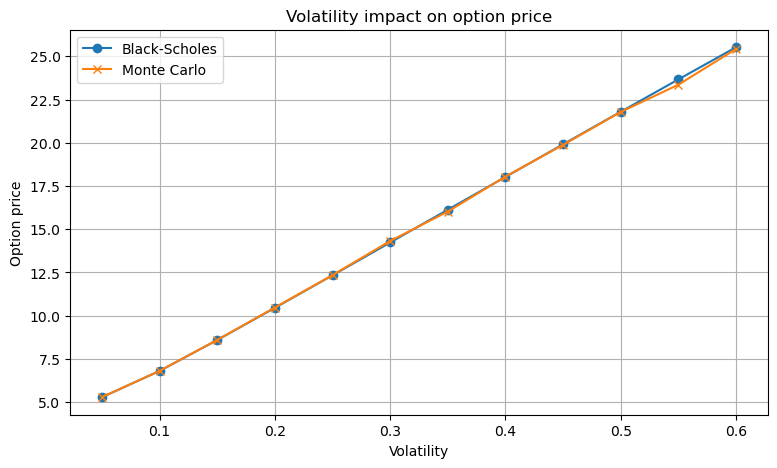

In [9]:
plot_volatility_analysis(vol_df, OUTPUT_DIR)

# Greeks via finite differences

Greeks estimate the sensitivity of the option value to each model input. Their theoretical formulas are given by:

$$
\Delta = \frac{\partial V}{\partial S}
$$

$$
\Gamma = \frac{\partial^2 V}{\partial S^2}
$$

$$
\text{Vega} = \frac{\partial V}{\partial \sigma}
$$

$$
\Theta = \frac{\partial V}{\partial T}
$$

$$
\rho = \frac{\partial V}{\partial r}
$$

where:

- $V$ is the option price
- $S$ is the underlying asset price
- $\sigma$ is the volatility
- $T$ is the time to maturity
- $r$ is the risk-free interest rate


Greeks will be approximated as follows:

$$
\Delta \approx \frac{V(S+h)-V(S-h)}{2h}
$$

$$
\Gamma \approx \frac{V(S+h)-2V(S)+V(S-h)}{h^2}
$$

$$
\text{Vega} \approx \frac{V(\sigma+h)-V(\sigma-h)}{2h}
$$

$$
\rho \approx \frac{V(r+h)-V(r-h)}{2h}
$$

$$
\Theta \approx - \frac{V(T+h) - V(T-h)}{2h}
$$


In [13]:
greeks_closed_form = black_scholes_greeks(params)

greeks_bs_fd = finite_difference_greeks(params, method='black_scholes', n_sim=100_000, seed=42)

greeks_mc_fd = finite_difference_greeks(params, method='monte_carlo', n_sim=100_000, seed=42)

greeks_df = pd.DataFrame([greeks_closed_form, greeks_bs_fd, greeks_mc_fd])

greeks_df

,method,option_type,price,delta,gamma,vega,theta,rho,vega_per_1pct_vol,theta_per_day,rho_per_1pct_rate
0,closed_form,call,10.450584,0.636831,0.018762,37.524035,-6.414028,53.232482,0.375240,-0.017573,0.532325
1,black_scholes,call,10.450584,0.636745,0.018760,37.520983,-6.414031,53.232481,0.375210,-0.017573,0.532325
2,monte_carlo,call,10.467314,0.637755,0.018280,37.610331,-6.427171,53.317461,0.376103,-0.017609,0.533175


# Effect of volatility on Greeks

In [15]:
greeks_vol_df = greeks_by_volatility(
    params=params,
    vol_grid=vol_grid,
    method="black_scholes",
)
greeks_vol_df

,volatility,method,option_type,price,delta,gamma,vega,theta,rho,vega_per_1pct_vol,theta_per_day,rho_per_1pct_rate
0,0.050000,black_scholes,call,5.283269,0.845634,0.047217,23.277069,-4.562236,79.448555,0.232771,-0.012499,0.794486
1,0.100000,black_scholes,call,6.804958,0.708469,0.034280,34.254571,-4.918675,64.079070,0.342546,-0.013476,0.640791
2,0.150000,black_scholes,call,8.591658,0.658334,0.024463,36.694239,-5.615586,57.256892,0.366942,-0.015385,0.572569
3,0.200000,black_scholes,call,10.450584,0.636745,0.018760,37.520983,-6.414031,53.232481,0.375210,-0.017573,0.532325
4,0.250000,black_scholes,call,12.335999,0.627351,0.015136,37.840619,-7.250500,50.404947,0.378406,-0.019864,0.504049
5,0.300000,black_scholes,call,14.231255,0.624208,0.012647,37.942549,-8.101196,48.193918,0.379425,-0.022195,0.481939
6,0.350000,black_scholes,call,16.128429,0.624669,0.010837,37.928491,-8.954671,46.341906,0.379285,-0.024533,0.463419
7,0.400000,black_scholes,call,18.022951,0.627381,0.009460,37.841643,-9.804304,44.717995,0.378416,-0.026861,0.447180
8,0.450000,black_scholes,call,19.911770,0.631582,0.008378,37.702983,-10.645684,43.248876,0.377030,-0.029166,0.432489
9,0.500000,black_scholes,call,21.792604,0.636809,0.007505,37.523810,-11.475541,41.890461,0.375238,-0.031440,0.418905


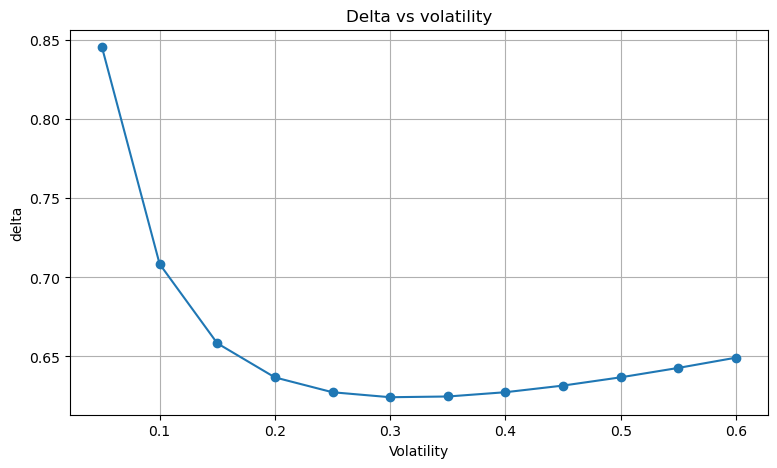

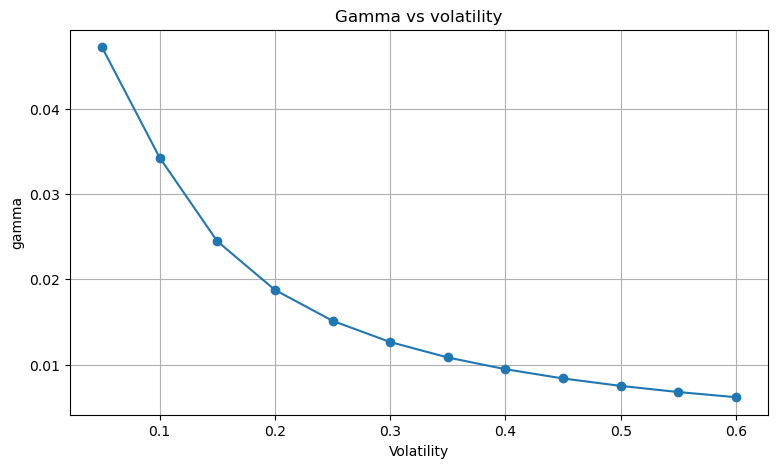

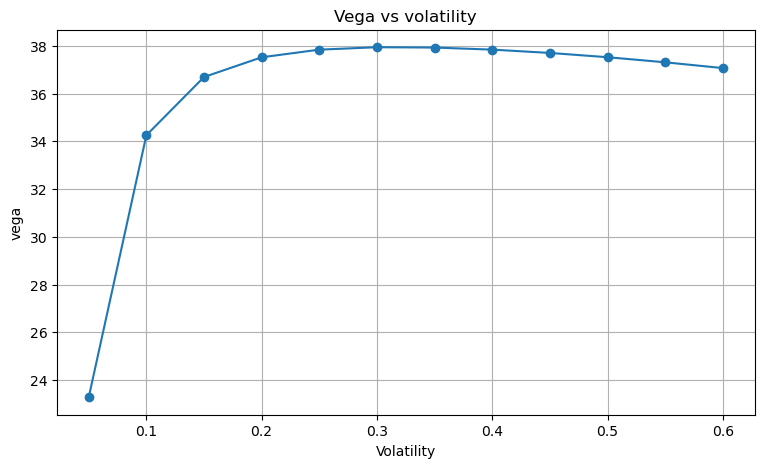

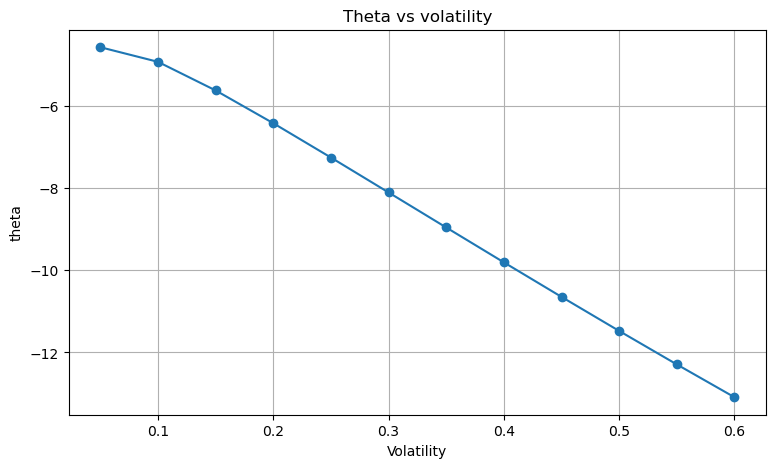

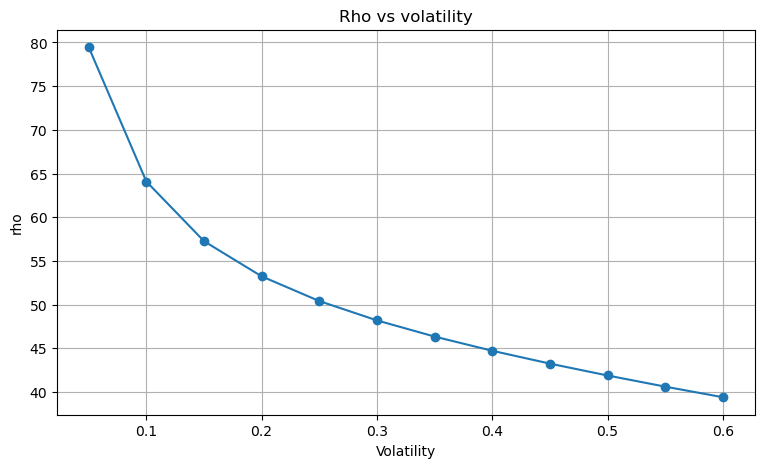

In [16]:
for greek in ['delta', 'gamma', 'vega', 'theta', 'rho']:
    plot_greek_by_volatility(greeks_vol_df, greek, OUTPUT_DIR)